# Day 5 — WaveNet (makemore Part 5, 56m)

Starter = part 3's end state, verbatim (his words 1:41: "the starter code for part five is very similar to where we ended up in part three... I've changed very few things"). The changes he names: per-layer generators dropped for one global torch.manual_seed(42). EVERYTHING below runs before the video starts changing things: block 3, flat net, ugly plot, eval, sampler.

**his path (performance log):** starter block-3, 12K params: train 2.058 / val 2.105 → context 8: val 2.027 → hierarchical: 2.029 → mid-video fix: 2.022 → scaled 76K params: train 1.769 / **val 1.993**. beat 1.993.

In [161]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [162]:
# ---- dashboard (starter = part 3 values; the video grows these) ----
BLOCK_SIZE = 8          # video extends to 8
N_EMBD = 10
N_HIDDEN = 200
MAX_STEPS = 200000
BATCH_SIZE = 32
LEARNING_RATE = 0.1

In [163]:
# read words, build vocab
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(len(words), vocab_size)

32033 27


In [164]:
# shuffle + split at the top, like always
import random
random.seed(42)
random.shuffle(words)

def build_dataset(word_list, block_size):
  X, Y = [], []
  for w in word_list:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1], BLOCK_SIZE)
Xdev, Ydev = build_dataset(words[n1:n2], BLOCK_SIZE)
Xte,  Yte  = build_dataset(words[n2:], BLOCK_SIZE)

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [165]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [166]:
# my part-3 layers, pasted as-is (each line's ancestor lives in my bn.ipynb loop)
# -----------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # kaiming
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (running momentum update)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

In [167]:
# ---- my classes (built during video) ----
class Embedding:
    def __init__(self, num_embeddings, embedding_dim) -> None:
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x) -> Any:
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers) -> None:
        self.layers = layers

    def __call__(self, x) -> Any:
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
            
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [168]:
torch.manual_seed(42); # one global rng now — per-layer generators are gone

In [169]:
# starter network — my part-3 shape: C table + flat layers list
layers = [
  Embedding(vocab_size, N_EMBD),
  Flatten(),
  Linear(N_EMBD * BLOCK_SIZE, N_HIDDEN, bias=False), BatchNorm1d(N_HIDDEN), Tanh(),
  Linear(N_HIDDEN, vocab_size),
]

model = Sequential(layers)

with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # ~12K
for p in parameters:
  p.requires_grad = True

22097


In [170]:
# training loop (same as part 3)
lossi = []
for i in range(MAX_STEPS):
  ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward
  x = Xb
  logit = model(x)
  loss = F.cross_entropy(logit, Yb)

  # backward
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = LEARNING_RATE if i < 150000 else LEARNING_RATE / 10
  for p in parameters:
    p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{MAX_STEPS:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2847
  10000/ 200000: 2.0647
  20000/ 200000: 1.9722
  30000/ 200000: 2.0948
  40000/ 200000: 1.9738
  50000/ 200000: 2.1287
  60000/ 200000: 2.3574
  70000/ 200000: 1.9131
  80000/ 200000: 2.0735
  90000/ 200000: 2.0968
 100000/ 200000: 1.4963
 110000/ 200000: 2.1294
 120000/ 200000: 2.2324
 130000/ 200000: 2.2071
 140000/ 200000: 2.2326
 150000/ 200000: 1.8908
 160000/ 200000: 1.6867
 170000/ 200000: 2.0968
 180000/ 200000: 1.7824
 190000/ 200000: 1.9151


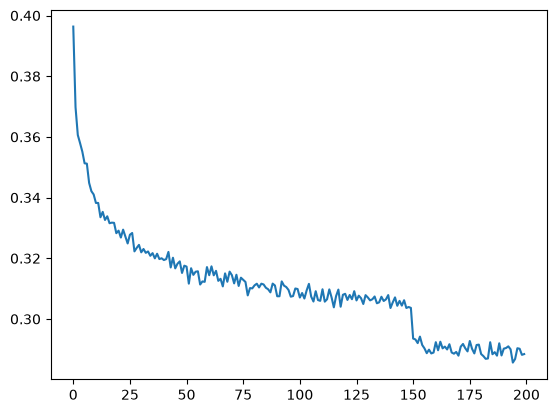

In [171]:
lossi = torch.tensor(lossi)
lossi = lossi.view(-1,1000).mean(1)
plt.plot(lossi)

In [172]:
# eval mode (batchnorm!), then split losses
for layer in layers:
  layer.training = False

@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logit = model(x)
  loss = F.cross_entropy(logit, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9163438081741333
val 2.034247636795044


In [173]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
  out = []
  context = [0] * BLOCK_SIZE
  while True:
    x = torch.tensor([context]) 
    logit = model(x)
    probs = F.softmax(logit, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

carmah.
amelle.
khyim.
shreet.
khaley.
kenrah.
brayder.
rutianni.
nellaiah.
maiir.
kaleigh.
hamoni.
miquil.
zaroia.
alivebi.
wanell.
dearyn.
kailee.
ivuan.
edde.


## observations

- starter run (block 3, 12K params, 200k steps): train 2.0583 / val 2.1065 — karpathy starter 2.058 / 2.105. matched almost exactly, same code same seed
- samples already name-ish at 2.10: carmahzabelle, quintis, eveigh
- torchified C + view into Embedding + Flatten classes. sampler bug on the way: Embedding[...] — indexed the CLASS, the lookup lives on the instance (self.weight). class = recipe, instance = table
- refactor payoff: train/eval/sample all had their own emb/view copies, now all three are just the layers loop on raw ints. forward logic lives in ONE place
- Sequential done. bugs on the way: __call__ fell off the end (silent None, would crash at cross_entropy far from cause) · built the wrapper INSIDE the training loop first (200k disposable objects — generator-in-loop family) · one run started at loss 1.68 not 3.3 = stale trained params, model cell not re-run. params persist, computation rebuilds
- refactor VERIFIED: full rerun after torchify — train 2.0583 / val 2.1065 and samples bit-identical to pre-class version. same seed, reorganized code, zero drift
- context 3 -> 8 (one dashboard change, Linear width followed automatically): 22097 params, train 1.9163 / val 2.0342 — karpathy 1.918 / 2.027. not bit-identical anymore (global rng state differs with run history), within 0.007 = healthy. context alone bought ~0.07 val. samples clearly better: kaleigh, kailee, brayder